In [2]:
import tables as tb
import numpy  as np
import pandas as pd
from scipy.optimize import curve_fit
import os

In [3]:
import matplotlib        as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
%matplotlib notebook
%matplotlib inline
### Useful parameters for plots
mpl.rcParams["figure.figsize"]          = 12,10
mpl.rcParams["font.size"]               = 20
mpl.rcParams["figure.max_open_warning"] = 100
mpl.rcParams["font.size"]               = 20
mpl.rcParams["font.weight"]             ='normal'
mpl.rcParams["axes.labelweight"] = "normal"
mpl.rcParams['axes.facecolor'] = 'w'
mpl.rcParams['figure.facecolor'] = 'w';

In [4]:
import invisible_cities.io.pmaps_io as pmapio
import invisible_cities.io.dst_io  as dstio

In [72]:
# To load and analyze a single run


filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_69.h5'

    
hits = pd.read_hdf(filepath_wf, "/MC/hits")
particles = pd.read_hdf(filepath_wf, "/MC/particles")



In [73]:
# here we load only gammas that are emitted by radiactive source

fe55_process = particles['event_id']
print(len(fe55_process))

fe55_process = particles[ (particles['particle_name'] == 'gamma') & (particles['mother_id'] == 1)]
#fe55_process = particles[ (particles['event_id'] == 1)]
#fe55_process['kev'] = fe55_process['kin_energy']  *1e3
print(fe55_process.head(50))



1385285
     event_id  particle_id particle_name  primary  mother_id  initial_x  \
3           0            6         gamma        0          1        0.0   
19          1            4         gamma        0          1        0.0   
40          2            5         gamma        0          1        0.0   
57          3            5         gamma        0          1        0.0   
76          4            4         gamma        0          1        0.0   
93          5            7         gamma        0          1        0.0   
112         6            6         gamma        0          1        0.0   
129         7            4         gamma        0          1        0.0   
146         8            7         gamma        0          1        0.0   
161         9            6         gamma        0          1        0.0   
175        10            5         gamma        0          1        0.0   
193        11            6         gamma        0          1        0.0   
211        12    

5.9    43581
5.8    22206
6.5     5954
6.4     2976
0.6      301
0.7       26
0.0        1
Name: keV, dtype: int64
0.13574110386550534


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_34350/494101703.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fe55_process['keV'] = fe55_process["kin_energy"]*1e3


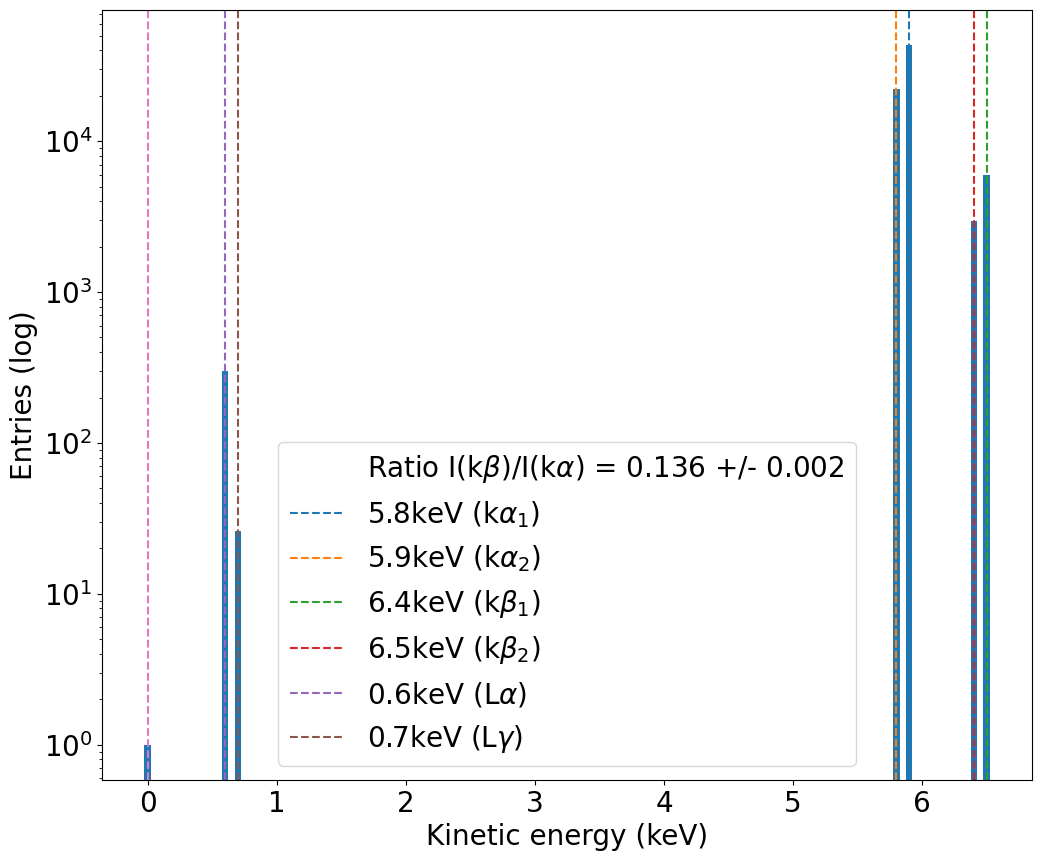

In [93]:
# Load energy kinetic of gammas and do analysis per energy peak

# We load energy kinetic of gammas and we group by decimals
fe55_process['keV'] = fe55_process["kin_energy"]*1e3
kin_ene = fe55_process["keV"].round(1).value_counts()


mask59 = (kin_ene.index >= 5.8) & (kin_ene.index <= 6)

mask65 = (kin_ene.index >= 6.2) & (kin_ene.index <= 6.5)

pk59 = np.sum(kin_ene.values[mask59]) 
pk65 = np.sum(kin_ene.values[mask65])
err_ratiopk = (pk65/pk59)*np.sqrt((1/pk65) + (1/pk59))
print(kin_ene)
print(pk65/pk59)


plt.bar(kin_ene.index, kin_ene.values, width=0.05)
plt.yscale('log')

label=['5.8keV (k$\\alpha_{1}$)', '5.9keV (k$\\alpha_{2}$)', '6.4keV (k$\\beta_{1}$)', '6.5keV (k$\\beta_{2}$)', '0.6keV (L$\\alpha$)', '0.7keV (L$\\gamma$)', '']
plt.plot(np.nan, np.nan, alpha=0, label=f'Ratio I(k$\\beta$)/I(k$\\alpha$) = {pk65/pk59:.3f} +/- {err_ratiopk:.3f}')
for i in range(len(kin_ene.index)):
    colorstr = f'C{i}'
    plt.axvline(kin_ene.index[i], color=colorstr, linestyle='--', label=label[i])
    
plt.xlabel('Kinetic energy (keV)')
plt.ylabel('Entries (log)')
plt.legend()
plt.show()






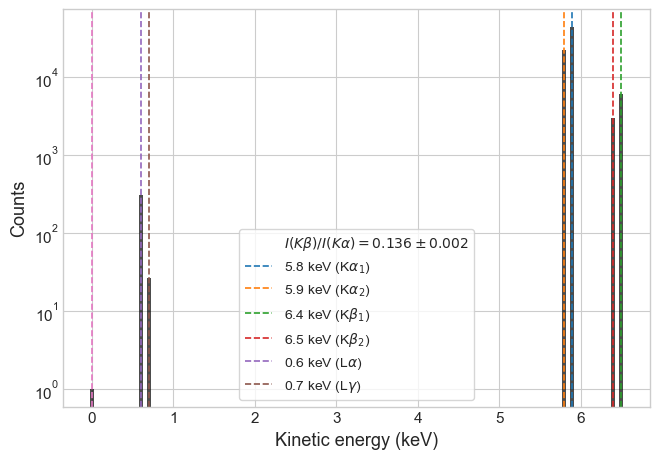

In [98]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Barres plus propres
plt.bar(kin_ene.index, kin_ene.values, width=0.05, color='black', alpha=0.7)

plt.yscale('log')

# Labels corrigés (typo physique)
label = [
    r'5.8 keV (K$\alpha_1$)',
    r'5.9 keV (K$\alpha_2$)',
    r'6.4 keV (K$\beta_1$)',
    r'6.5 keV (K$\beta_2$)',
    r'0.6 keV (L$\alpha$)',
    r'0.7 keV (L$\gamma$)',
    ''
]

# Ratio avec belle écriture
plt.plot([], [], ' ', label=rf'$I(K\beta)/I(K\alpha) = {pk65/pk59:.3f} \pm {err_ratiopk:.3f}$')

# Lignes verticales plus fines et sobres
for i in range(len(kin_ene.index)):
    colorstr = f'C{i}'
    plt.axvline(kin_ene.index[i], color=colorstr, linestyle='--', linewidth=1.2, label=label[i])

# Axes améliorés
plt.xlabel('Kinetic energy (keV)', fontsize=13)
plt.ylabel('Counts', fontsize=13)

# Ticks plus lisibles
plt.tick_params(axis='both', which='major', labelsize=11)

# Légende propre
plt.legend(fontsize=10, frameon=True)

# Marges propres
plt.tight_layout()

# Sauvegarde publication
plt.savefig("fe55_spectrum.pdf", dpi=300, bbox_inches='tight')

plt.show()

In [86]:
evid = fe55_process[(fe55_process['event_id'] == 12)]
dup = fe55_process[fe55_process['event_id'].duplicated()]

print(fe55_process['event_id'])
print(evid)
print('dup is :', dup)
print('len dup is :', len(dup))

3              0
19             1
40             2
57             3
76             4
           ...  
1385201    74713
1385213    74714
1385242    74715
1385259    74716
1385273    74717
Name: event_id, Length: 75045, dtype: int64
     event_id  particle_id particle_name  primary  mother_id  initial_x  \
211        12            6         gamma        0          1        0.0   

     initial_y  initial_z  initial_t  final_x  ...  initial_momentum_y  \
211        0.0  63.692501   0.000596  1.24669  ...            0.004175   

     initial_momentum_z  final_momentum_x final_momentum_y final_momentum_z  \
211           -0.003453               0.0              0.0             -0.0   

     kin_energy    length      creator_proc  final_proc       keV  
211    0.005848  3.311261  RadioactiveDecay        phot  5.847939  

[1 rows x 26 columns]
dup is :          event_id  particle_id particle_name  primary  mother_id  initial_x  \
6838          368            5         gamma        0          

In [112]:
ev_low = fe55_process[ (fe55_process['kin_energy'] >= 3/1e3) & (fe55_process['kin_energy'] <= 5.7/1e3)]

print(ev_low)

          event_id  particle_id particle_name  primary  mother_id  initial_x  \
101              6           10         gamma        0          6   0.060874   
132              8           10         gamma        0          6  -0.134199   
732             56            8         gamma        0          4  -0.127866   
866             65            9         gamma        0          5  -0.416095   
943             70           10         gamma        0          6   0.083639   
...            ...          ...           ...      ...        ...        ...   
12374519    999767            8         gamma        0          4  -0.012021   
12374555    999769           10         gamma        0          6  -0.268109   
12375797    999871            9         gamma        0          5   0.130890   
12376202    999905           11         gamma        0          6   0.352291   
12376857    999959           10         gamma        0          6   0.159320   

          initial_y  initial_z  initial

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_1811/1611994752.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fe55_process["kin_energy_round"] = fe55_process["kin_energy"].round(5)


Text(0, 0.5, 'Entries')

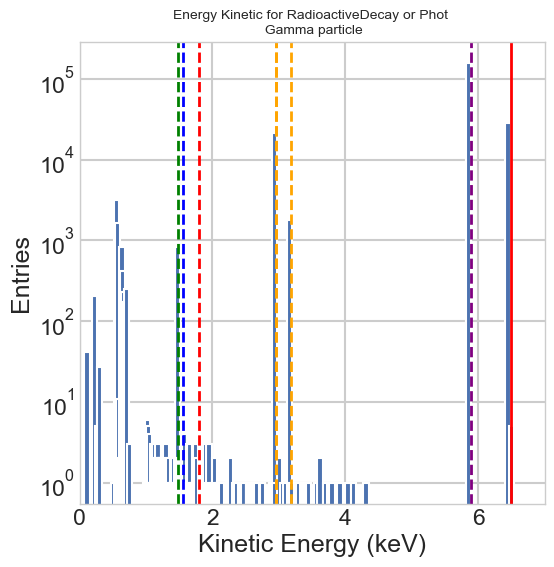

In [526]:
fe55_process["kin_energy_round"] = fe55_process["kin_energy"].round(5)
fe55_process_peak = fe55_process.groupby('kin_energy_round')['kin_energy_round'].agg(['size'])
#print(fe55_process_peak[fe55_process_peak['size']> 1])
#print(fe55_process_peak.reset_index()[['kin_energy_round']])
x = fe55_process_peak.reset_index()['kin_energy_round'].tolist()
x = np.array(x)
#for xval in x:
    #print(f'{xval*1e3:.5f}')
fig, ax = plt.subplots(figsize=(6,6))
ax.bar(x*1e3, fe55_process_peak['size'], width=0.08)

#plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
#plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
#plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
#plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
#plt.axvline(5.89, color='red', linestyle='-', linewidth=2)
plt.axvline(6.49, color='red', linestyle='-', linewidth=2)
ax.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')
ax.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
ax.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
ax.axvline(2.955, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
ax.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')

ax.axvline(3.19, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
#ax.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
ax.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
ax.set_title('Energy Kinetic for RadioactiveDecay or Phot \n Gamma particle', fontsize=10)
ax.set_yscale('log')
ax.set_xlim(0,7)
ax.set_xlabel('Kinetic Energy (keV)')
ax.set_ylabel('Entries')

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_1811/305709401.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


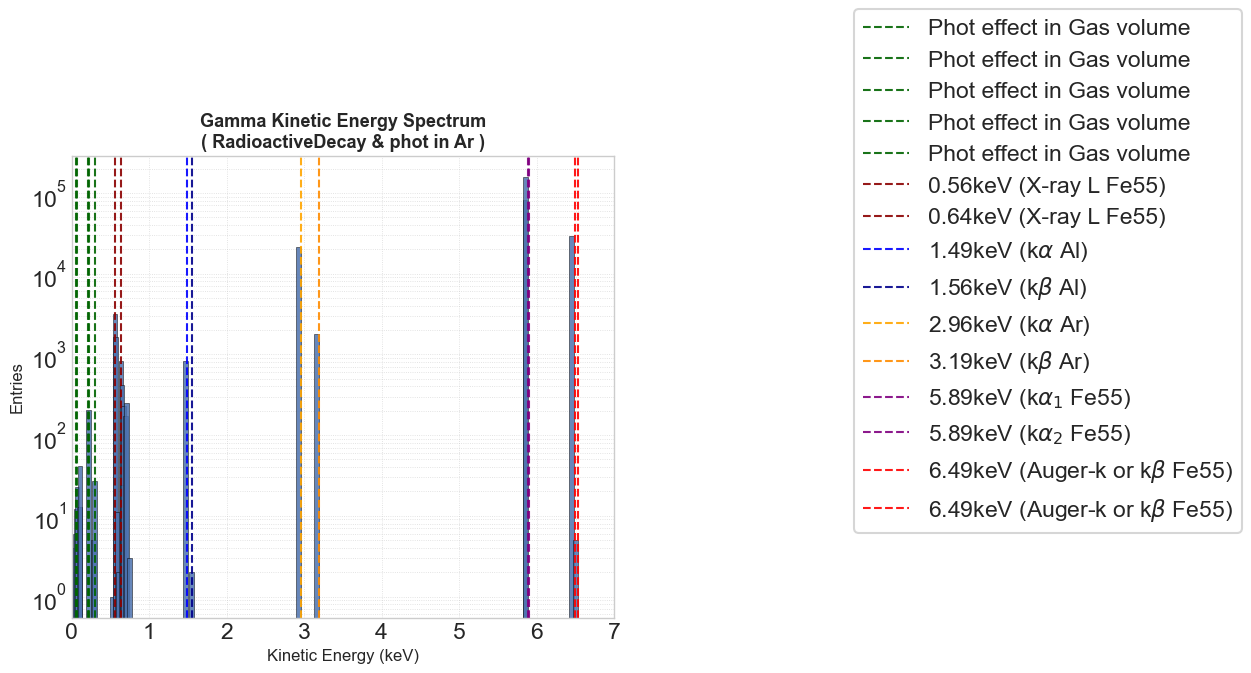

In [497]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize=(7,6))

# Histogramme (barres fines et propres)
ax.bar(
    x * 1e3,
    fe55_process_peak['size'],
    width=0.06,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85
)

# --- Lignes de référence ---
lines = [
    (0.064,  "Phot effect in Gas volume", "darkgreen"),
    (0.06,  "Phot effect in Gas volume", "darkgreen"),
    (0.218,  "Phot effect in Gas volume", "darkgreen"),
    (0.221,  "Phot effect in Gas volume", "darkgreen"),
    (0.299,  "Phot effect in Gas volume", "darkgreen"),
    (0.56,  "0.56keV (X-ray L Fe55)", "darkred"),
    (0.64,  "0.64keV (X-ray L Fe55)", "darkred"),
    (1.486, "1.49keV (k$\\alpha$ Al)", "blue"),
    (1.557, "1.56keV (k$\\beta$ Al)", "darkblue"),
    #(1.8,   "1.8 keV Xe", "red"),
    (2.955, "2.96keV (k$\\alpha$ Ar)", "orange"),
    (3.19,  "3.19keV (k$\\beta$ Ar)", "darkorange"),
    (5.8877,  "5.89keV (k$\\alpha_{1}$ Fe55)", "purple"),
    (5.8988,  "5.89keV (k$\\alpha_{2}$ Fe55)", "purple"),
    (6.49,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    (6.54,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    
]

for energy, label, color in lines:
    ax.axvline(
        energy,
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.9,
        label=label
    )

# --- Mise en forme ---
ax.set_title(
    "Gamma Kinetic Energy Spectrum\n( RadioactiveDecay & phot in Ar )",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Kinetic Energy (keV)", fontsize=12)
ax.set_ylabel("Entries", fontsize=12)

ax.set_yscale("log")
ax.set_xlim(0, 7)

ax.legend(
    loc='center',
    bbox_to_anchor=(1.8, 0.75),  # <-- coordonnées personnalisées
    frameon=True
)

ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()


/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_11265/1617626262.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fe55_process["kin_energy_round"] = fe55_process["kin_energy"].round(5)
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_11265/1617626262.py:76: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


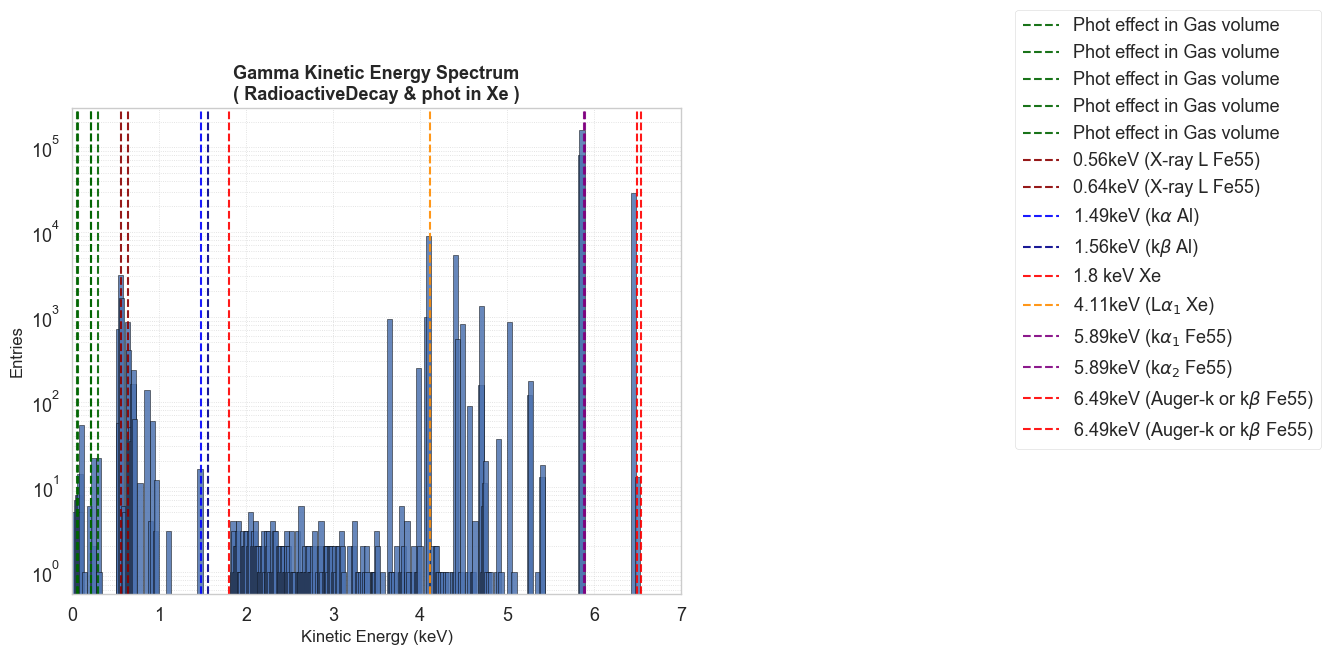

In [127]:
import matplotlib.pyplot as plt
fe55_process["kin_energy_round"] = fe55_process["kin_energy"].round(5)
fe55_process_peak = fe55_process.groupby('kin_energy_round')['kin_energy_round'].agg(['size'])
#print(fe55_process_peak[fe55_process_peak['size']> 1])
#print(fe55_process_peak.reset_index()[['kin_energy_round']])
x = fe55_process_peak.reset_index()['kin_energy_round'].tolist()
x = np.array(x)
plt.style.use("seaborn-whitegrid")

fig, ax = plt.subplots(figsize=(7,6))

# Histogramme (barres fines et propres)
ax.bar(
    x * 1e3,
    fe55_process_peak['size'],
    width=0.06,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85
)

# --- Lignes de référence ---
lines = [
    (0.064,  "Phot effect in Gas volume", "darkgreen"),
    (0.06,  "Phot effect in Gas volume", "darkgreen"),
    (0.218,  "Phot effect in Gas volume", "darkgreen"),
    (0.221,  "Phot effect in Gas volume", "darkgreen"),
    (0.299,  "Phot effect in Gas volume", "darkgreen"),
    (0.56,  "0.56keV (X-ray L Fe55)", "darkred"),
    (0.64,  "0.64keV (X-ray L Fe55)", "darkred"),
    (1.486, "1.49keV (k$\\alpha$ Al)", "blue"),
    (1.557, "1.56keV (k$\\beta$ Al)", "darkblue"),
    (1.8,   "1.8 keV Xe", "red"),
    #(2.955, "2.96keV (k$\\alpha$ Ar)", "orange"),
    #(3.19,  "3.19keV (k$\\beta$ Ar)", "darkorange"),
    (4.11,  "4.11keV (L$\\alpha_{1}$ Xe)", "darkorange"),
    (5.8877,  "5.89keV (k$\\alpha_{1}$ Fe55)", "purple"),
    (5.8988,  "5.89keV (k$\\alpha_{2}$ Fe55)", "purple"),
    (6.49,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    (6.54,  "6.49keV (Auger-k or k$\\beta$ Fe55)", "red"),
    
]

for energy, label, color in lines:
    ax.axvline(
        energy,
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.9,
        label=label
    )

# --- Mise en forme ---
ax.set_title(
    "Gamma Kinetic Energy Spectrum\n( RadioactiveDecay & phot in Xe )",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Kinetic Energy (keV)", fontsize=12)
ax.set_ylabel("Entries", fontsize=12)

ax.set_yscale("log")
ax.set_xlim(0, 7)

ax.legend(
    loc='center',
    bbox_to_anchor=(1.8, 0.75),  # <-- coordonnées personnalisées
    frameon=True
)

ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()


In [39]:
import matplotlib.pyplot as plt
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'tableau-colorblind10']


Empty DataFrame
Columns: [event_id, particle_id, particle_name, primary, mother_id, initial_x, initial_y, initial_z, initial_t, final_x, final_y, final_z, final_t, initial_volume, final_volume, initial_momentum_x, initial_momentum_y, initial_momentum_z, final_momentum_x, final_momentum_y, final_momentum_z, kin_energy, length, creator_proc, final_proc]
Index: []

[0 rows x 25 columns]


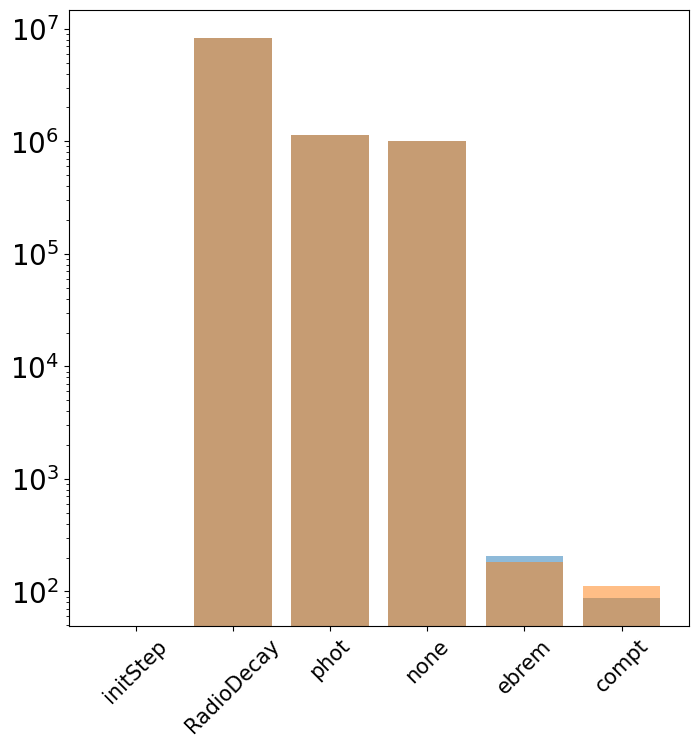

In [76]:
runs = [41, 42]
xlabels = ['initStep', 'RadioDecay', 'phot', 'none', 'ebrem', 'compt']
xaxis = np.arange(0, len(xlabels), 1)
fig, ax = plt.subplots(figsize=(8,8))
for i in range(len(runs)):
    

    filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+str(runs[i])+'.h5'


    hits = pd.read_hdf(filepath_wf, "/MC/hits")
    particles = pd.read_hdf(filepath_wf, "/MC/particles")

    other_proc = particles[(particles['creator_proc'] != 'initStep') 
                           & (particles['creator_proc'] != 'RadioactiveDecay')
                          & (particles['creator_proc'] != 'phot')
                          & (particles['creator_proc'] != 'none')
                          & (particles['creator_proc'] != 'eBrem')
                          & (particles['creator_proc'] != 'compt')]

    initStep = particles[(particles['creator_proc'] == 'initStep')]
    RadioDecay = particles[(particles['creator_proc'] == 'RadioactiveDecay')]
    phot = particles[(particles['creator_proc'] == 'phot')]
    none = particles[(particles['creator_proc'] == 'none')]
    ebrem = particles[(particles['creator_proc'] == 'eBrem')]
    compt = particles[(particles['creator_proc'] == 'compt')]
    
    
    
    yval = [len(initStep), len(RadioDecay), len(phot), len(none), len(ebrem), len(compt)]
    ax.bar(xaxis, yval, alpha=0.5)
    
ax.set_xticks(xaxis)
ax.set_xticklabels(xlabels, fontsize=15, rotation=45)
ax.set_yscale('log')
print(other_proc.head(10))



0
Empty DataFrame
Columns: [event_id, particle_id, particle_name, primary, mother_id, initial_x, initial_y, initial_z, initial_t, final_x, final_y, final_z, final_t, initial_volume, final_volume, initial_momentum_x, initial_momentum_y, initial_momentum_z, final_momentum_x, final_momentum_y, final_momentum_z, kin_energy, length, creator_proc, final_proc]
Index: []

[0 rows x 25 columns]


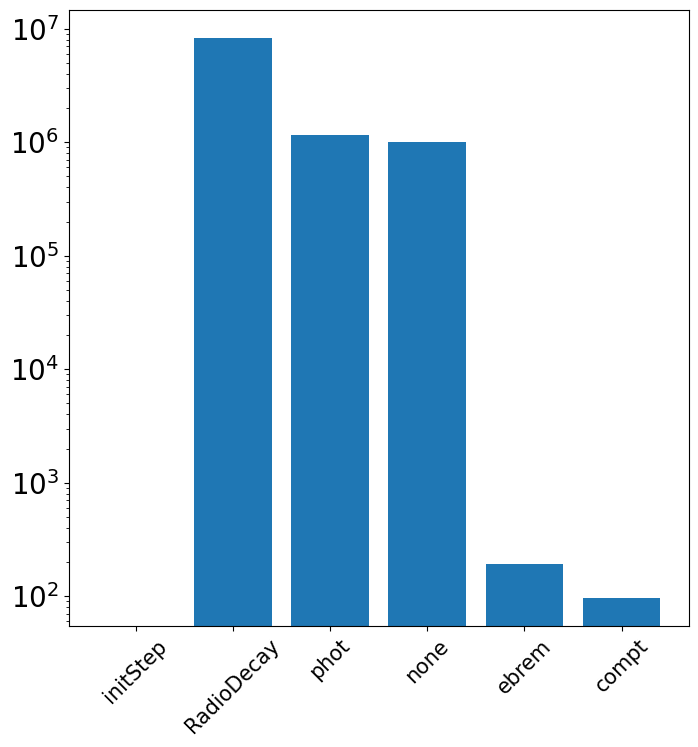

In [43]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
energy_study = particles[(particles['kin_energy'] > 4/1e3) & (particles['kin_energy'] < 4.3/1e3)]

energy_study['energy_kev'] = energy_study['kin_energy'] * 1e3

#energy_study.head(100)

particle_study = particles[(particles['particle_id'] == 1) & (particles['event_id'] == 1)]

particle_study.head(100)

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_58687/3062737824.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  energy_study['energy_kev'] = energy_study['kin_energy'] * 1e3


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,final_y,final_z,final_t,initial_volume,final_volume,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
18,1,1,Fe55,1,0,0.0,0.0,67.692497,0.0,0.0,0.0,67.692497,0.001881,GasDrift,GasDrift,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none,RadioactiveDecay


In [37]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
event_study = hits[(hits['event_id'] == 55)]


event_study.head(100)

,event_id,x,y,z,time,energy,label,particle_id,hit_id
1151,55,-1.166856e-04,-0.000044,67.692589,0.114898,4.930334e-07,DRIFT,9,0
1152,55,-2.405930e-03,0.000265,67.697495,0.000355,7.049448e-04,DRIFT,8,0
1153,55,-2.589484e-03,0.002085,67.700592,0.000446,5.487446e-05,DRIFT,8,1
1154,55,3.870711e-04,0.004516,67.702179,0.000552,1.424951e-04,DRIFT,8,2
1155,55,1.896611e-03,0.008341,67.702324,0.000658,3.215998e-05,DRIFT,8,3
1156,55,2.769246e-03,0.015219,67.704361,0.000846,3.022989e-03,DRIFT,8,4
1157,55,3.454137e-03,0.013670,67.703667,0.001036,2.132067e-05,DRIFT,8,5
1158,55,3.844129e-03,0.013348,67.703247,0.001067,5.007185e-05,DRIFT,8,6
1159,55,4.580701e-03,0.012740,67.702461,0.001128,5.724721e-05,DRIFT,8,7
1160,55,4.569404e-03,0.012595,67.702324,0.001138,2.999254e-04,DRIFT,8,8


In [172]:
gamma = particles[(particles['particle_name'] == 'gamma')]
gamma_keV = gamma['kin_energy'] * 1000
gamma.loc[(gamma['kin_energy'] > 0/1000) & (gamma['kin_energy'] < 1/1000)]


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
1910,147,5,gamma,0,1,0.00000,0.000000,67.692497,0.001107,-0.022833,...,-0.000107,-0.000354,-0.000420,-0.0,-0.0,-0.0,0.000560,0.119020,RadioactiveDecay,phot
2612,204,8,gamma,0,1,0.00000,0.000000,67.692497,0.000232,0.007025,...,0.000174,0.000642,-0.000236,0.0,0.0,-0.0,0.000706,0.028430,RadioactiveDecay,phot
2932,232,6,gamma,0,1,0.00000,0.000000,67.692497,0.000905,0.036305,...,0.000517,-0.000388,-0.000079,0.0,-0.0,-0.0,0.000651,0.045753,RadioactiveDecay,phot
12694,1023,5,gamma,0,1,0.00000,0.000000,67.692497,0.000657,0.126325,...,0.000507,-0.000234,0.000036,0.0,-0.0,0.0,0.000560,0.139425,RadioactiveDecay,phot
15601,1261,10,gamma,0,5,0.03142,0.033324,67.630226,0.001558,0.073730,...,0.000124,0.000193,-0.000477,0.0,0.0,-0.0,0.000530,0.180160,phot,phot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12364371,999330,5,gamma,0,1,0.00000,0.000000,67.692497,0.001740,-0.029232,...,-0.000175,-0.000459,-0.000289,-0.0,-0.0,-0.0,0.000570,0.095015,RadioactiveDecay,phot
12368609,999667,9,gamma,0,1,0.00000,0.000000,67.692497,0.000231,0.034182,...,0.000416,-0.000374,-0.000004,0.0,-0.0,-0.0,0.000560,0.046001,RadioactiveDecay,phot
12370131,999793,7,gamma,0,1,0.00000,0.000000,67.692497,0.003652,-0.105946,...,-0.000152,-0.000288,0.000468,-0.0,-0.0,0.0,0.000570,0.397083,RadioactiveDecay,phot
12371319,999887,8,gamma,0,4,0.13814,0.166830,67.813370,0.001132,0.194651,...,0.000403,-0.000580,-0.000489,0.0,-0.0,-0.0,0.000859,0.120487,phot,phot


In [173]:
gamma_filter = gamma[(gamma['kin_energy'] > 2/1000) & (gamma['kin_energy'] < 4/1000)]
#gamma_filter.loc[(gamma_filter['creator_proc'] == 'RadioactiveDecay')]
gamma_filter.loc[(gamma_filter['particle_name'] == 'gamma')]

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
2152,168,9,gamma,0,5,0.005052,-0.005308,67.676781,0.000069,-0.116720,...,-0.000255,0.001895,-0.003113,-0.0,0.0,-0.0,0.003653,1.745378,phot,phot
17054,1372,8,gamma,0,4,0.944093,-0.655924,67.627449,0.005126,1.091838,...,0.000832,-0.002384,-0.002639,0.0,-0.0,-0.0,0.003653,0.648926,phot,phot
17614,1413,8,gamma,0,4,-0.034122,0.041094,68.145134,0.002195,-0.437077,...,-0.001275,-0.003336,0.000766,-0.0,-0.0,0.0,0.003653,1.154326,phot,phot
26466,2128,8,gamma,0,4,-0.181549,0.187733,67.225449,0.001955,-0.098622,...,0.003255,-0.000764,0.001471,0.0,-0.0,0.0,0.003653,0.093064,phot,phot
30268,2439,9,gamma,0,5,-0.130891,0.055283,67.705811,0.003967,0.430176,...,0.001397,-0.000391,-0.003352,0.0,-0.0,-0.0,0.003653,1.466546,phot,phot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12336500,997025,10,gamma,0,6,-0.166010,2.583333,67.878563,0.009567,-0.160413,...,0.003158,0.000715,0.001690,0.0,0.0,0.0,0.003653,0.006473,phot,phot
12337795,997134,63,gamma,0,9,0.006007,0.004001,67.685493,0.000770,0.513355,...,0.001531,0.002332,-0.001913,0.0,0.0,-0.0,0.003383,1.120766,eBrem,phot
12338246,997168,11,gamma,0,7,0.140541,-0.006918,67.583397,0.003974,-0.073055,...,-0.000723,0.002114,-0.003296,-0.0,0.0,-0.0,0.003982,1.177010,phot,phot
12341242,997404,12,gamma,0,8,0.005760,-0.281419,67.767487,0.001342,0.050505,...,0.000272,0.002379,0.002758,0.0,0.0,0.0,0.003653,0.600564,phot,phot


353
269963
The ratio between the 5.9keV and the 1.4keV peaks is :  764.7677053824362


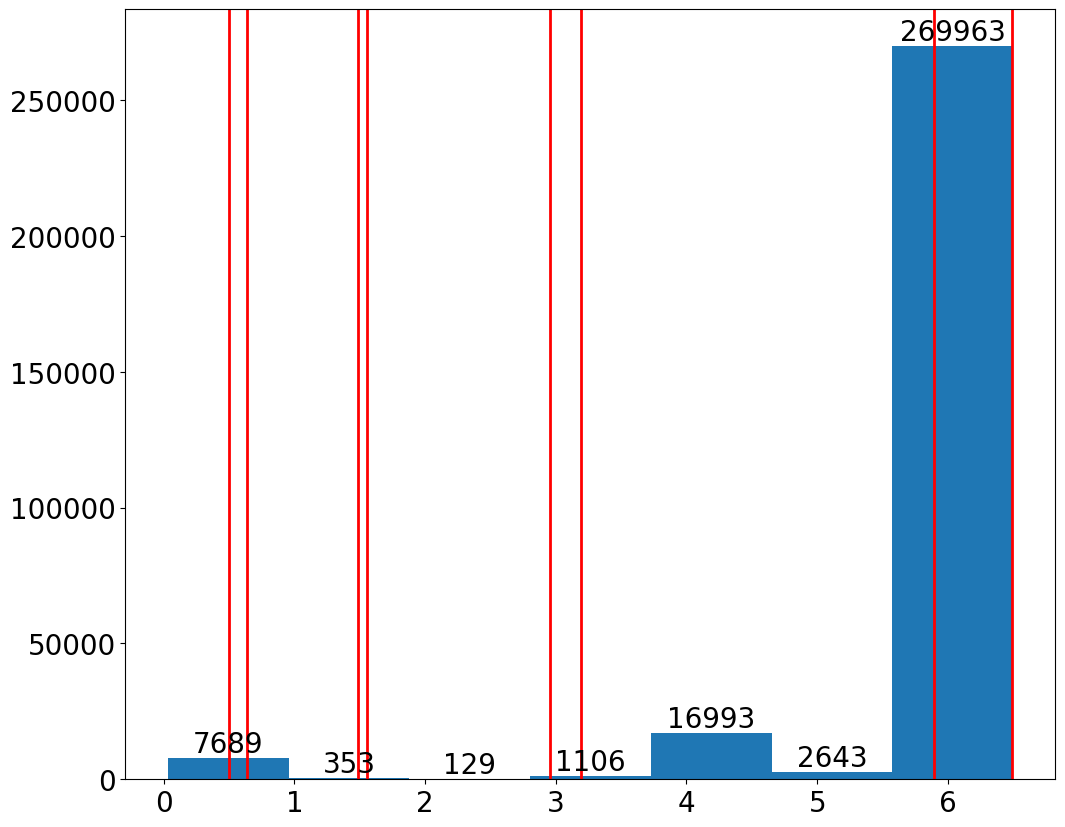

In [174]:
counts, bins, patches = plt.hist(gamma_keV, bins = 7)
plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
plt.axvline(5.89, color='red', linestyle='-', linewidth=2)
plt.axvline(6.49, color='red', linestyle='-', linewidth=2)

count_store = []

for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    bin_center = (bin_left + bin_right) / 2
    plt.text(bin_center, count, str(int(count)), ha='center', va='bottom', fontsize=20)
    count_store.append(count)
print(str(int(count_store[1])))
print(str(int(count_store[6])))
print("The ratio between the 5.9keV and the 1.4keV peaks is : ", count_store[6]/count_store[1])

#plt.yscale('log')

In [21]:
hits.loc[(hits['event_id'] == 2)]





,event_id,x,y,z,time,energy,label,particle_id,hit_id
50,2,-0.000123,0.000175,67.693016,0.426773,4.930334e-07,DRIFT,6,0
51,2,0.003296,-0.001446,67.695503,0.001284,5.784741e-04,DRIFT,4,0
52,2,-0.000029,0.000101,67.692596,0.000993,3.841456e-05,DRIFT,3,0
53,2,0.000015,-0.000128,67.692451,0.000993,3.540312e-05,DRIFT,2,0


# start of analysis

In [102]:

filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/xenon/GaP_Fe55_Xenon_Alu_4.0.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_100000.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_5.h5'
#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_100.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_45.h5'



#for i in range(len(pressure)):
# filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/alu_6.5bar_294kel.h5'

#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/xenon/GaP_Fe55_Xenon_Alu_'+str(pressure[i])+'.h5'
#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/results/GaP_Fe55_runs/argon/1000000evts_Argon/GaP_Fe55_Argon_Alu_'+str(pressure[i])+'.h5'
print(filepath_wf)
hits = pd.read_hdf(filepath_wf, "/MC/hits")
particles = pd.read_hdf(filepath_wf, "/MC/particles")

#hits.to_csv("/Users/ldonneger/Desktop/hits.txt", sep="\t", index=False)
#particles.to_csv("/Users/ldonneger/Desktop/particles.txt", sep="\t", index=False)




/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_45.h5


In [85]:
pd.set_option('display.max_columns', 500)
alu = particles[(particles['initial_volume'] == 'AluminumFoil') & (particles['particle_name'] == 'gamma')]
print(alu)

        event_id  particle_id particle_name  primary  mother_id  initial_x  \
8863         841           13         gamma        0          9  -0.834541   
21072       2003            9         gamma        0          5   2.734166   
72167       6873           10         gamma        0          6  -3.099128   
79204       7539           10         gamma        0          6   4.700519   
92014       8746           10         gamma        0          6   2.463961   
94206       8958           17         gamma        0         10  -0.693193   
103307      9822           11         gamma        0          7  -1.295018   

        initial_y  initial_z  initial_t   final_x   final_y   final_z  \
8863     3.637340   1.415162   0.015203 -0.833907  3.638260  1.412166   
21072    2.348447   1.411731   0.013822  2.750506  2.351436  1.415891   
72167    2.695980   1.415018   0.015468 -3.098076  2.698519  1.409705   
79204    0.689131   1.410713   0.016859  4.681624  0.707671  1.410315   
92014   -0

In [103]:
event_id = hits['event_id']
event_max = event_id.max()
print(event_max)


999999


In [104]:

%%time
#sum energy dep event by event
#pressure = np.arange(2, 8.5, 0.5)


edep_store = []
edep = hits[(hits['label'] == 'DRIFT')]
edep['energy_kev'] = edep['energy'] * 1e3

for j in range(0, event_max):
#for j in range(0, 1000):
 
    edep2 = edep[(edep['event_id'] == j)]
    
    edep_store.append(edep2.energy_kev.sum())


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/magics/execution.py", line 1325, in time
    exec(code, glob, local_ns)
  File "<timed exec>", line 12, in <module>
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/pandas/core/frame.py", line 3449, in __getitem__
    return self._getitem_bool_array(key)
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/pandas/core/frame.py", line 3503, in _getitem_bool_array
    indexer = key.nonzero()[0]
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 2105, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/IPython/core/ultratb.py", line 1396, in structured_

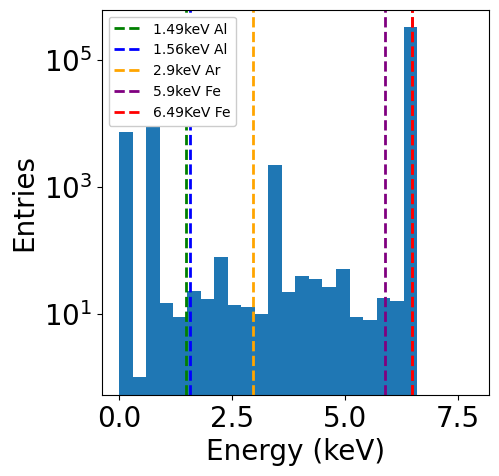

In [106]:
edep_store = np.array(edep_store)
bins = np.arange(0, 8, 0.3)
#mask = (edep_store >= 0.5)
plt.figure(figsize=(5,5))
counts, bins, patches = plt.hist(edep_store, bins = bins, density=False)
mask_59 = (edep_store >= 5) & (edep_store <= 6)
mask_59 = (edep_store >= 5) & (edep_store <= 6)
#plt.xlim(0,7)
#plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
#plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
#plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
#plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
#plt.axvline(5.89, color='red', linestyle='-', linewidth=2)
plt.axvline(6.49, color='red', linestyle='--', linewidth=2)
#plt.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')


plt.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
plt.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
plt.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
#plt.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
plt.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
plt.axvline(6.49, color='red', linestyle='--', linewidth=2, label='6.49KeV Fe')
plt.yscale('log')
plt.ylabel('Entries')
plt.xlabel('Energy (keV)')
plt.legend(loc='upper left', fontsize=10, framealpha=1)
plt.show()

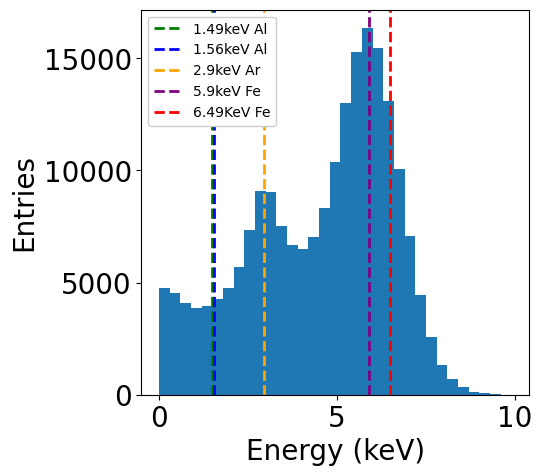

In [17]:
energy = 5.9

sigma_init = 0.15
resolution = []
edep_store1 = edep_store
edep_store1 = np.array(edep_store1)

for i in range(len(edep_store1)):
    sigma_smear = np.sqrt(edep_store[i]/energy)*sigma_init
    smear59 = np.random.normal(1, sigma_smear, 1)
    edep_store1[i] = edep_store1[i] * smear59

bins = np.arange(0, 10, 0.3)
#mask = (edep_store >= 0.5)
plt.figure(figsize=(5,5))
counts, bins, patches = plt.hist(edep_store1, bins = bins, density=False)
#plt.xlim(0,7)
#plt.axvline(0.64, color='red', linestyle='-', linewidth=2)
#plt.axvline(0.5, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.486, color='red', linestyle='-', linewidth=2)
#plt.axvline(1.557, color='red', linestyle='-', linewidth=2)
#plt.axvline(2.957, color='red', linestyle='-', linewidth=2)
#plt.axvline(3.190, color='red', linestyle='-', linewidth=2)
#plt.axvline(5.89, color='red', linestyle='-', linewidth=2)

#plt.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')
plt.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
plt.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
plt.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
#plt.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
plt.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
plt.axvline(6.49, color='red', linestyle='--', linewidth=2, label='6.49KeV Fe')
#plt.yscale('log')
plt.ylabel('Entries')
plt.xlabel('Energy (keV)')
plt.legend(loc='upper left', fontsize=10, framealpha=1)
plt.show()

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_37.h5
130829
33
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_38.h5
124875
33


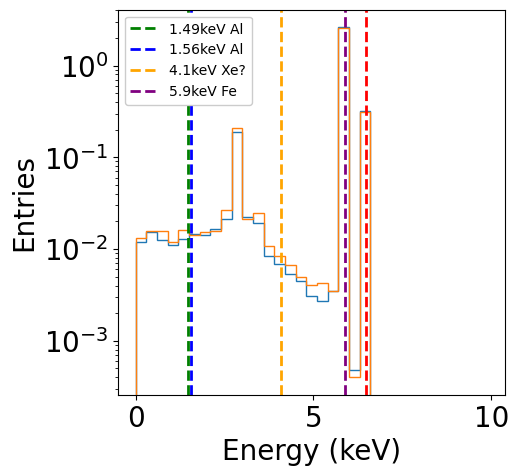

     count37   count38      diff
0   0.011975  0.013106  0.001132
1   0.015516  0.015536  0.000019
2   0.012663  0.015722  0.003060
3   0.011134  0.011985  0.000851
4   0.013020  0.015936  0.002916
5   0.014574  0.014201  0.000373
6   0.014268  0.015509  0.001241
7   0.016332  0.015722  0.000609
8   0.021427  0.026426  0.004999
9   0.189586  0.209863  0.020277
10  0.022115  0.021088  0.001028
11  0.019262  0.024878  0.005616
12  0.008484  0.010918  0.002433
13  0.006854  0.008328  0.001475
14  0.005300  0.006700  0.001400
15  0.004459  0.004912  0.000453
16  0.003057  0.004057  0.001000
17  0.002726  0.004244  0.001518
18  0.003491  0.003524  0.000033
19  2.617259  2.579353  0.037906
20  0.000484  0.000400  0.000084
21  0.319348  0.310924  0.008424
22  0.000000  0.000000  0.000000
23  0.000000  0.000000  0.000000
24  0.000000  0.000000  0.000000
25  0.000000  0.000000  0.000000
26  0.000000  0.000000  0.000000
27  0.000000  0.000000  0.000000
28  0.000000  0.000000  0.000000
29  0.0000

/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_6819/657888291.py:58: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(-5, 5)


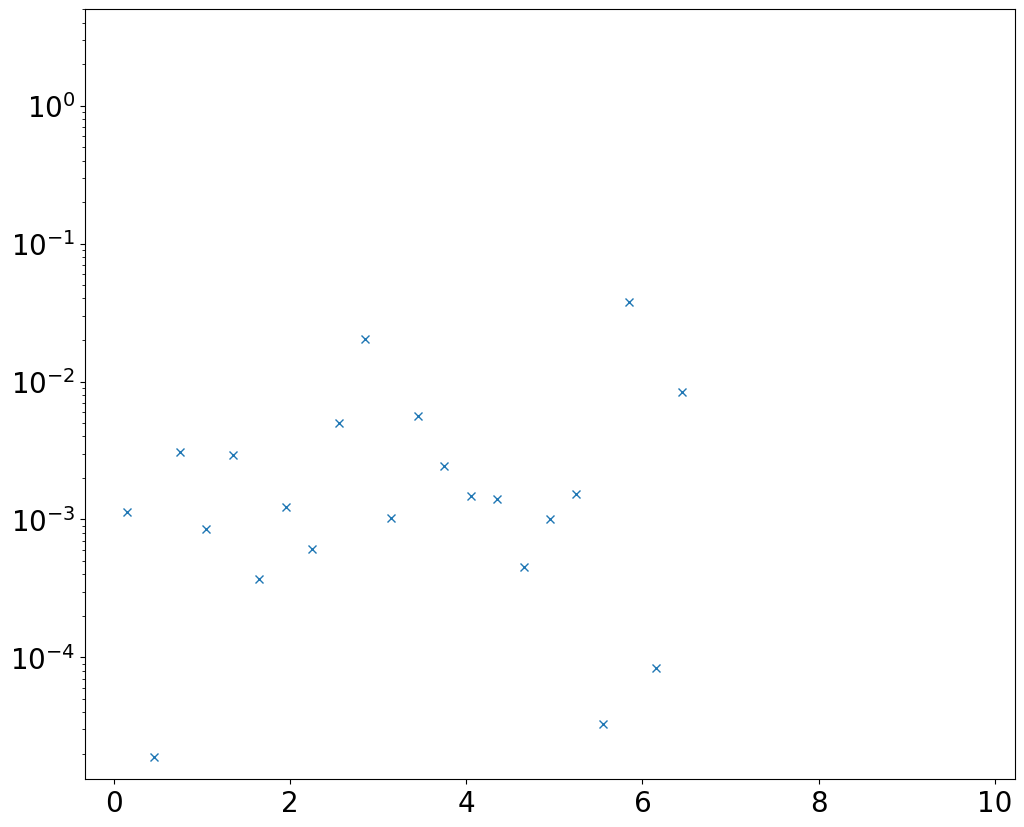

In [22]:
run_nb = [37, 38]
plt.figure(figsize=(5,5))
count_diff = pd.DataFrame({})
for i in range(len(run_nb)):
    
    filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+str(run_nb[i])+'.h5'
    print(filepath_wf)
    hits = pd.read_hdf(filepath_wf, "/MC/hits")
    particles = pd.read_hdf(filepath_wf, "/MC/particles")

    event_id = hits['event_id']
    event_max = event_id.max()
    print(event_max)

    #%%time
    #sum energy dep event by event
    #pressure = np.arange(2, 8.5, 0.5)


    edep_store = []
    edep = hits[(hits['label'] == 'DRIFT')]
    edep['energy_kev'] = edep['energy'] * 1e3

    for j in range(0, event_max):
    #for j in range(0, 1000):

        edep2 = edep[(edep['event_id'] == j)]

        edep_store.append(edep2.energy_kev.sum())

    edep_store = np.array(edep_store)
    bins = np.arange(0, 10, 0.3)
    #mask = (edep_store >= 0.5)
    
    
    counts, bins, patches = plt.hist(edep_store, bins = bins, density=True, histtype='step')
    print(len(counts))
    count_diff['count'+str(run_nb[i])] = counts
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

plt.axvline(6.49, color='red', linestyle='--', linewidth=2)
#plt.axvline(1.8, color='red', linestyle='--', linewidth=2, label='1.8keV Xe')
plt.axvline(1.486, color='green', linestyle='--', linewidth=2, label='1.49keV Al')
plt.axvline(1.557, color='blue', linestyle='--', linewidth=2, label='1.56keV Al')
#plt.axvline(2.957, color='orange', linestyle='--', linewidth=2, label='2.9keV Ar')
plt.axvline(4.1, color='orange', linestyle='--', linewidth=2, label='4.1keV Xe?')
plt.axvline(5.89, color='purple', linestyle='--', linewidth=2, label='5.9keV Fe')
plt.yscale('log')
plt.ylabel('Entries')
plt.xlabel('Energy (keV)')
plt.legend(loc='upper left', fontsize=10, framealpha=1)
plt.show() 

count_diff['diff'] = np.abs(count_diff['count'+str(run_nb[0])] - count_diff['count'+str(run_nb[1])])

plt.errorbar(bin_centers, count_diff['diff'], marker='x', linestyle='')
plt.yscale('log')
plt.ylim(-5, 5)
plt.axhline(0, color='red', linewidth=2)
#plt.xlim(0, 1e-2)
print(count_diff)
    

# Check MC waveforms (Adelma)

In [31]:
pmt_sample_size = 0.1 # in µs

In [221]:
#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_3/simGanESS/results/elfield/'
#main_path   = '/home/investigator/GanEss//GanESS_G4Sim/simGanESS/results/100/'
run_nb = '32'
#filepath_wf = main_path + filename_wf
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_1_adelma.h5'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_2_adelma.h5'
#filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_10000_adelma.h5'
#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_mod_2_wt_EL/simGanESS/'
filepath_wf = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+run_nb+'_adelma.h5'

!ptdump $filepath_wf
#!ptdump -vd $filepath_wf:/pmtrd
#!ptdump -vd $filepath_wf:/Filters/detected_events
#!ptdump -vd $filepath_wf:/Filters/signal
#!ptdump -vd $filepath_wf:/MC
#!ptdump -vd $filepath_wf:/MC/event_mapping
#!ptdump -vd $filepath_wf:/MC/hits
#!ptdump -vd $filepath_wf:/MC/particles
#!ptdump -vd $filepath_wf:/MC/sns_positions
#!ptdump -vd $filepath_wf:/MC/sns_response
#!ptdump -vd $filepath_wf:/Run/eventMap
#!ptdump -vd $filepath_wf:/Run/events
#!ptdump -vd $filepath_wf:/Run/runInfo
#!ptdump -v $filepath_wf:/config/adelma
#!ptdump -dv $filepath_wf:/pmtrd

   
    
    
    
#!ptdump -vd $filepath_wf:/MC/particles
    

/ (RootGroup) ''
/pmtrd (EArray(7791, 7, 1400)shuffle, zlib(4)) ''
/Filters (Group) ''
/Filters/detected_events (Table(7793,)shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/signal (Table(7791,)shuffle, zlib(4)) 'Event has passed filter flag'
/MC (Group) ''
/MC/configuration (Table(34,)shuffle, zlib(4)) ''
/MC/event_mapping (Table(7791,)shuffle, zlib(4)) ''
/MC/hits (Table(143276,)shuffle, zlib(4)) ''
/MC/particles (Table(146067,)shuffle, zlib(4)) ''
/MC/sns_positions (Table(7,)shuffle, zlib(4)) ''
/MC/sns_response (Table(2622568,)shuffle, zlib(4)) ''
/Run (Group) ''
/Run/eventMap (Table(7791,)shuffle, zlib(4)) 'event & nexus evt for each index'
/Run/events (Table(7791,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(7791,)shuffle, zlib(4)) 'run info table'
/config (Group) ''
/config/adelma (Table(12,)shuffle, zlib(4)) 'configuration for adelma'


[0 1 2 3 4 5]
7791
[10.67062782 26.1313725   1.24558709]
popt[0]  10.670627822118904 popt[2]  1.2455870875280255


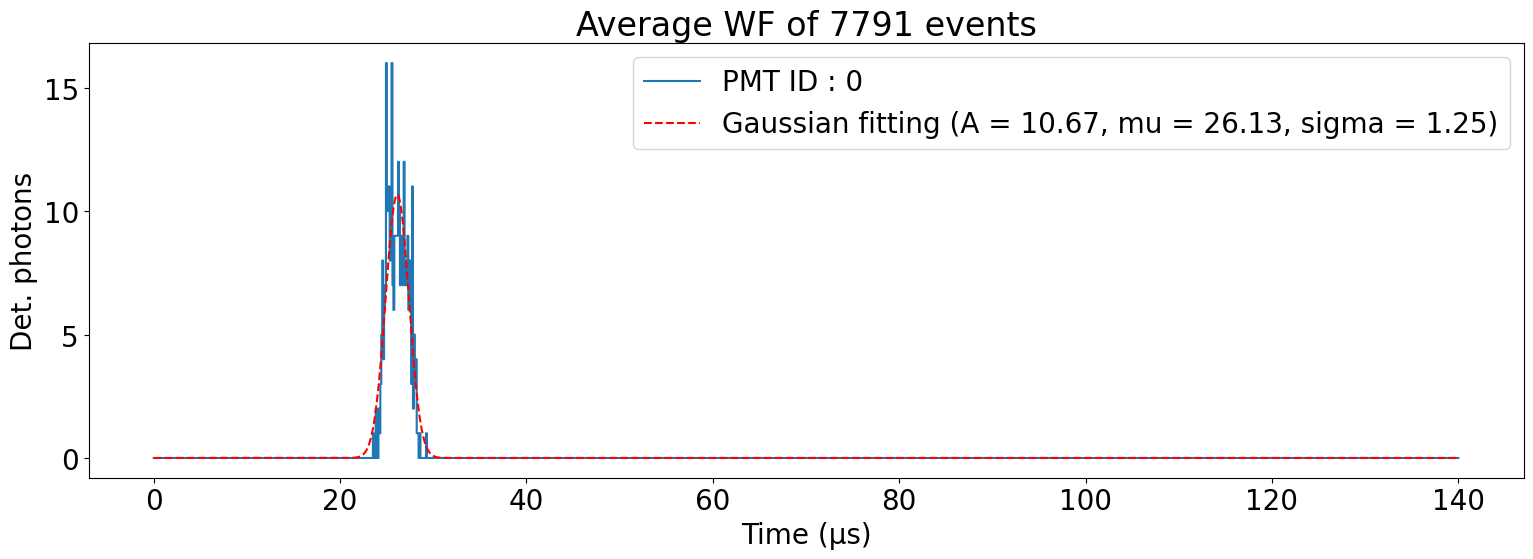

[10.99707799 26.37499345 -1.27530341]
popt[0]  10.99707799260781 popt[2]  -1.2753034074954057


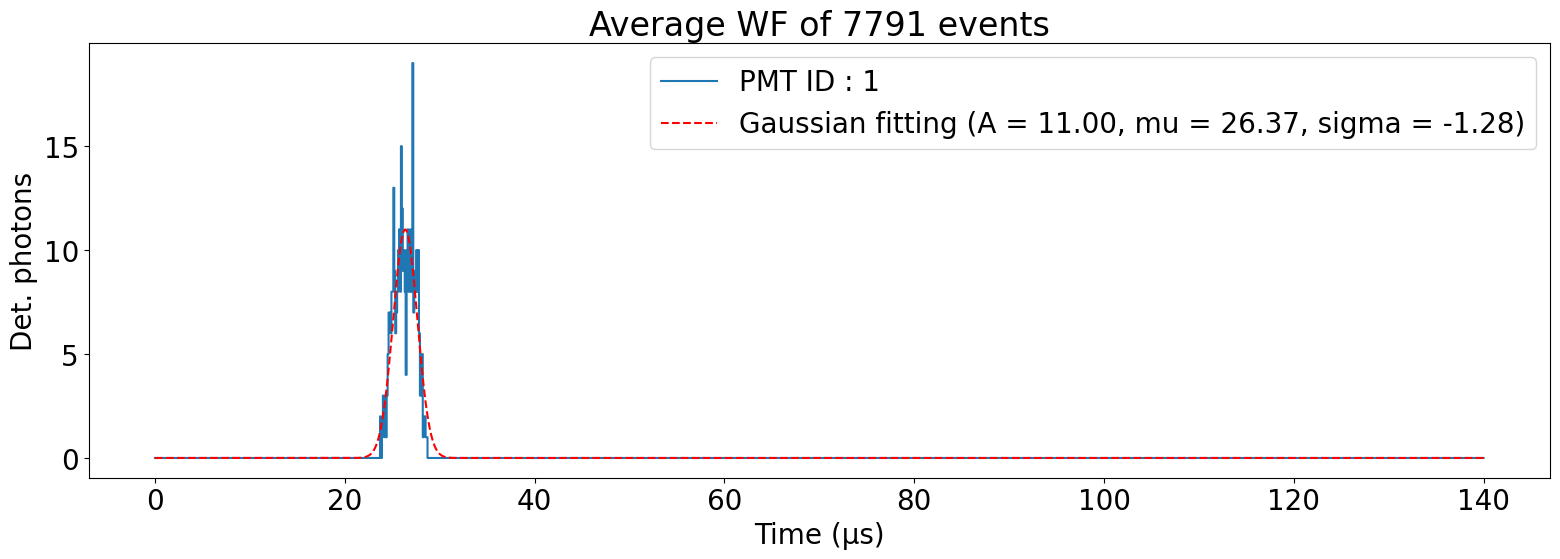

[11.13507599 26.4375046  -1.22935737]
popt[0]  11.135075993565742 popt[2]  -1.2293573704688445


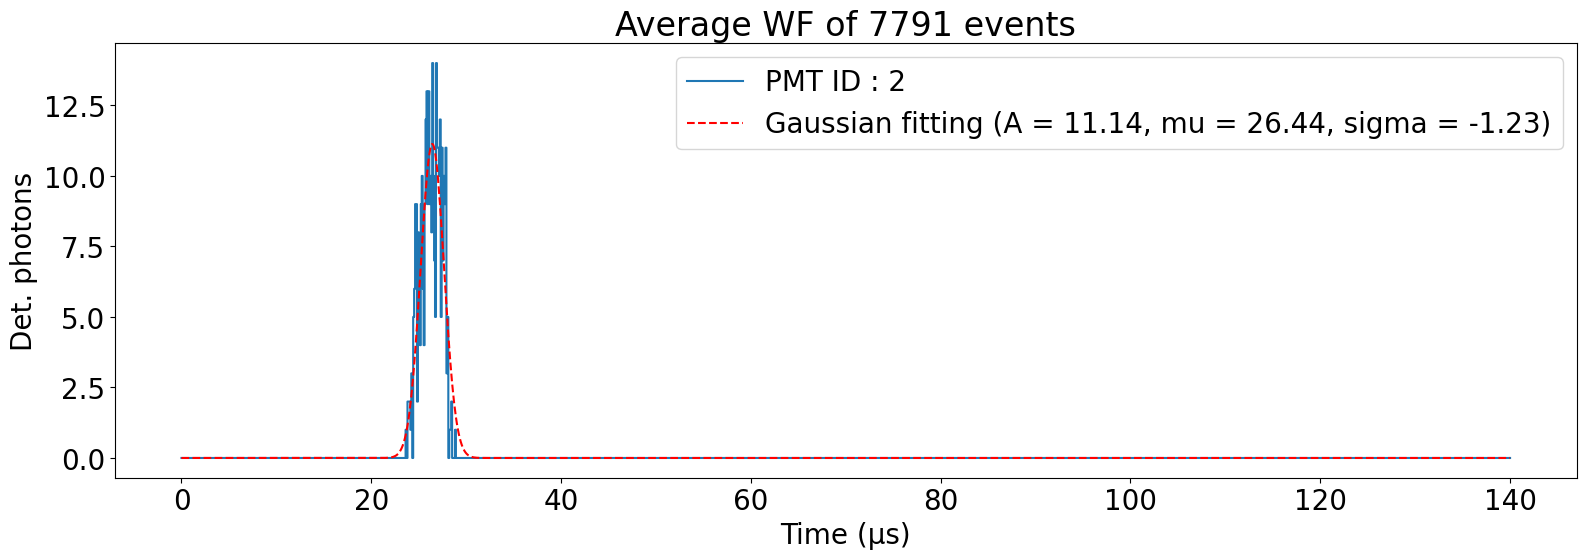

[41.10947691 26.58681192  1.31093678]
popt[0]  41.10947691398179 popt[2]  1.3109367812526238


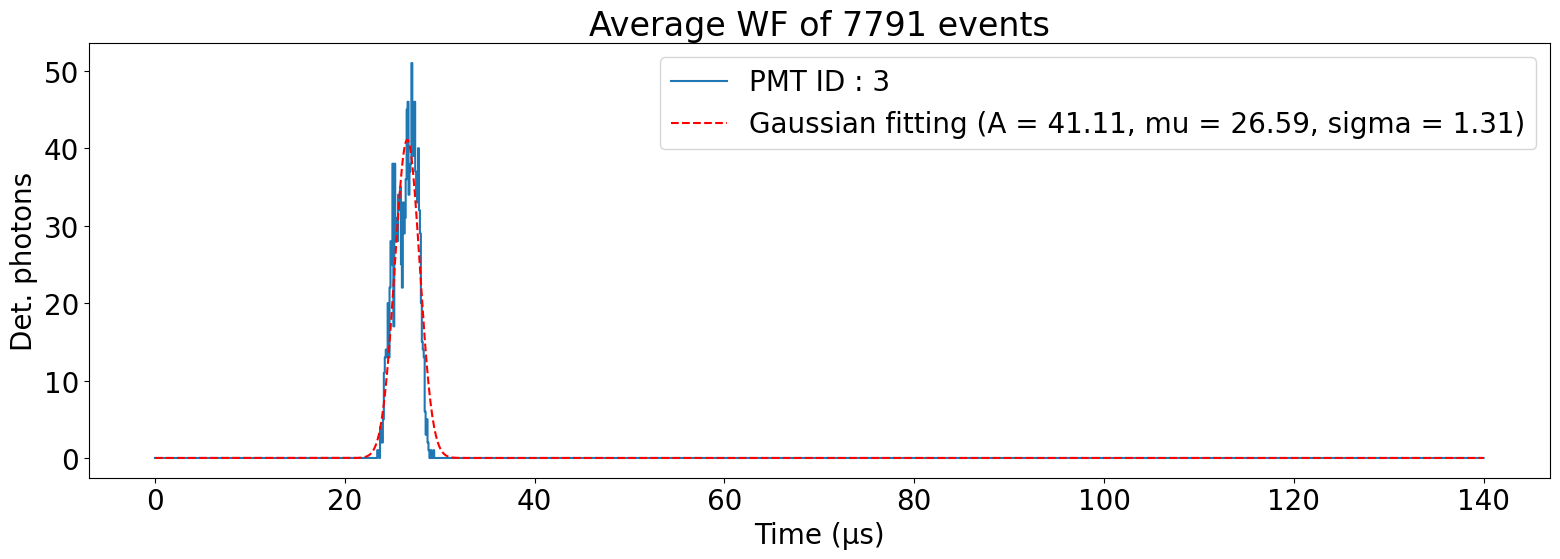

[10.28513062 26.34200303 -1.34750196]
popt[0]  10.285130624945971 popt[2]  -1.3475019577578868


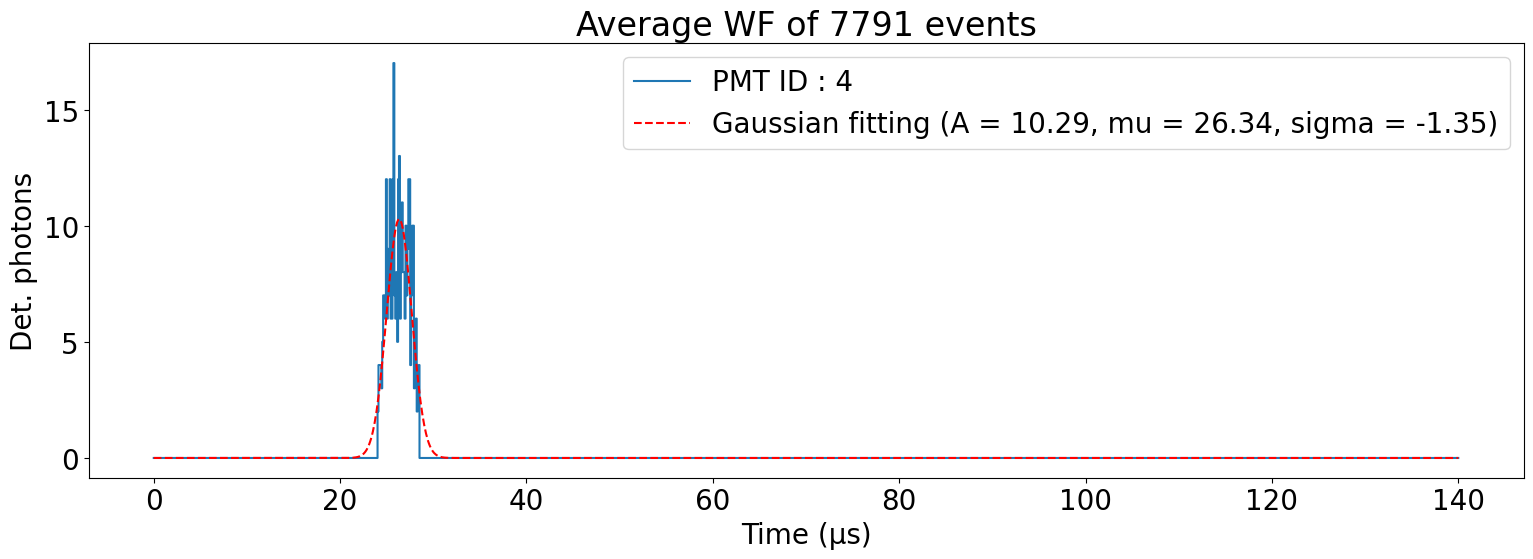

[10.18810706 26.31015737  1.35708104]
popt[0]  10.188107059132712 popt[2]  1.35708103631837


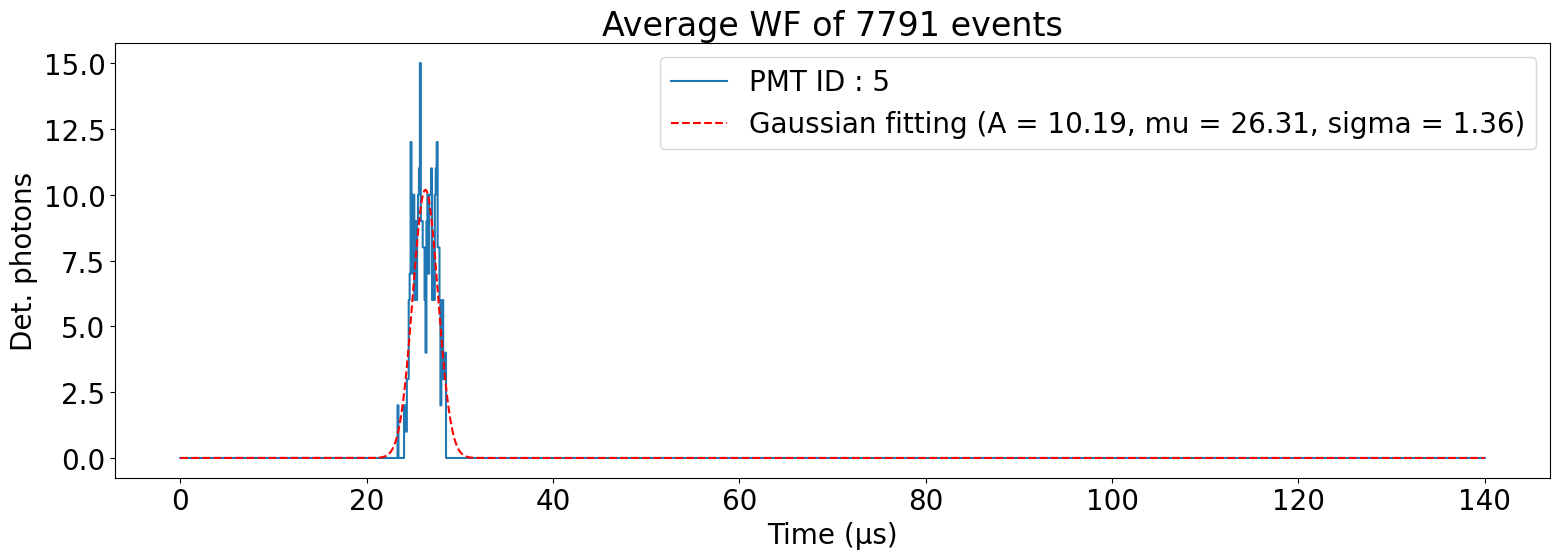

In [222]:
def gauss(x,amp,mu,sigma):
    return amp*np.exp(-(x-mu)**2/(2*sigma**2))
tab = []
inf = 0
pmt_rwf = []
pmt_id = np.arange(0,6)
pi = np.pi
charges = []
print(pmt_id)
with tb.open_file(filepath_wf, 'r') as h5in:
    tab[:] = h5in.root.pmtrd
    print(len(tab))
    sup = len(tab)
    for pmt in pmt_id:
        #print(pmt)
        pmt_rwf_tot = []
        moy = []
        plt.figure(figsize=(16, 6))
        for j in range(inf,sup):
            pmt_rwf[:] = h5in.root.pmtrd[j][pmt]#[0] # WF seen in each PMTs
            t = np.linspace(0, len(pmt_rwf)*pmt_sample_size, len(pmt_rwf))
            pmt_rwf_tot.append(pmt_rwf)
            #print(pmt_rwf[900])
            #print(pmt_rwf_tot)
            #print(t)
            #plt.plot(t, pmt_rwf, drawstyle='steps', lw=1.5, label='PMT ID : ')
            #plt.legend()
            #plt.xlabel('Time (µs)')
            #plt.ylabel('Det. photons')
            #plt.title('Event number : '+str(j))
            #plt.tight_layout()
            #print(f'PMT ID Number : {i}')

        moy = [sum(colonne)/(sup - inf) for colonne in zip(*pmt_rwf_tot)]
        #print(moy[900])
        plt.plot(t, moy, drawstyle='steps', lw=1.5, label='PMT ID : '+str(pmt))
        plt.legend()
        plt.xlabel('Time (µs)')
        plt.ylabel('Det. photons')
        plt.title('Average WF of '+str(sup-inf)+' events')
        plt.tight_layout()
        
        popt,pcov = curve_fit(gauss,t,moy,p0=(8,20,5))

        y = gauss(t,popt[0],popt[1],popt[2])

        plt.plot(t,y,color='r',linestyle='dashed',label=f'Gaussian fitting (A = {popt[0]:.2f}, mu = {popt[1]:.2f}, sigma = {popt[2]:.2f})')
        
        print(popt)
        charges.append(popt[0]*popt[2]*(2*pi)**0.5)
        print('popt[0] ', popt[0], 'popt[2] ', popt[2])
        #print(f'Charge is : {charges[pmt]}')
        plt.legend()
        #plt.savefig("/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/Average_WF.png", format="png", bbox_inches="tight",dpi=300)
        plt.show()






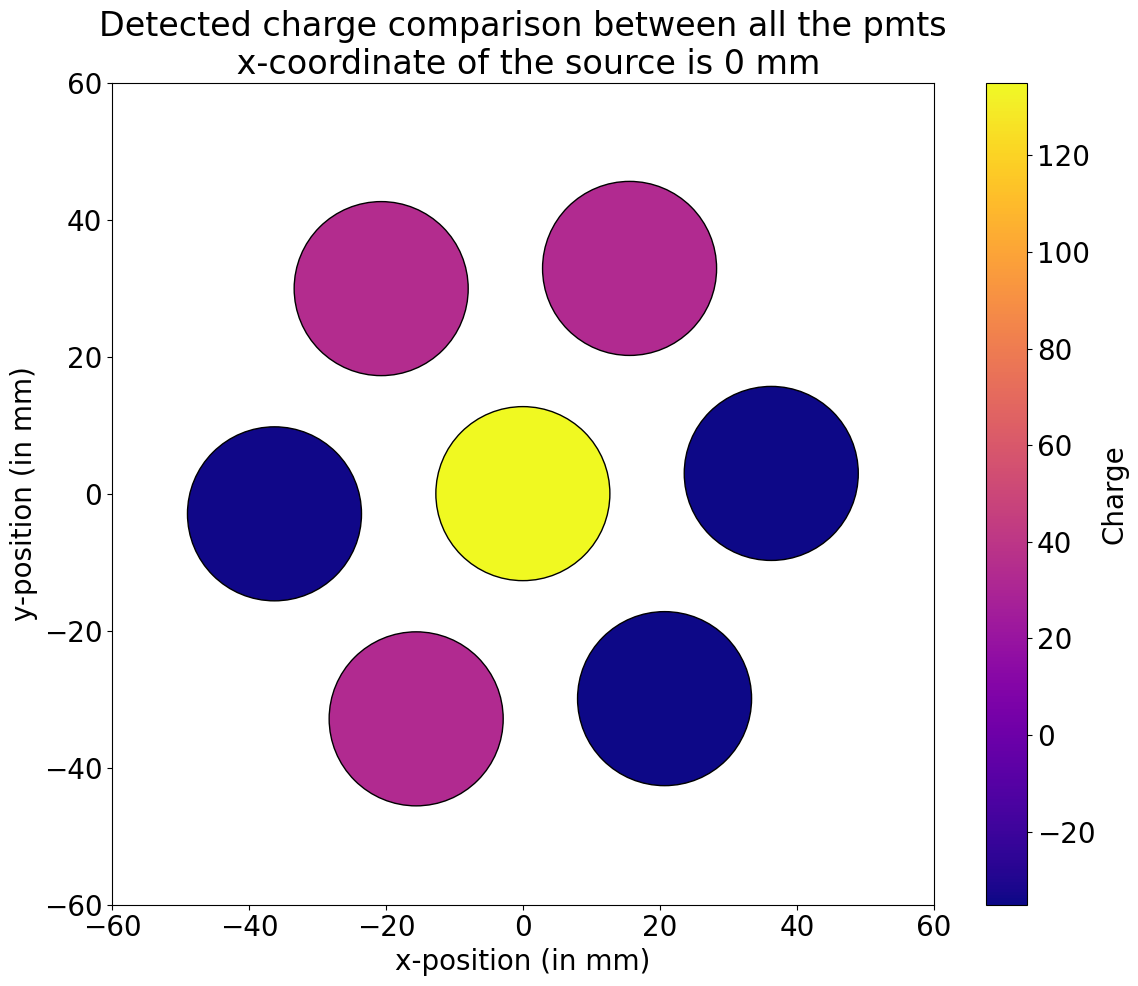

In [223]:
x_coord = np.arange(0,32,2)
pmt_rad = 25.4

positions = [(-15.573, -32.871), (20.68, -29.922), (-36.253, -2.949), (0., 0.), (36.253, 2.949), (-20.68, 29.922), (15.573, 32.871)]       # (x, y) centre des ellipses
sizes = [(pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad), (pmt_rad, pmt_rad)]       # (width, height)
#charges = [10, 25, 5, 5, 5, 5, 5]                      # couleur = charge


patches = []
for (x, y), (w, h) in zip(positions, sizes):
    ellipse = Ellipse((x, y), width=w, height=h)
    patches.append(ellipse)


collection = PatchCollection(patches, cmap='plasma', edgecolor='black')
collection.set_array(np.array(charges))  # couleurs = charges


fig, ax = plt.subplots()
ax.add_collection(collection)
plt.colorbar(collection, ax=ax, label='Charge')


ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.set_aspect('equal')
plt.xlabel('x-position (in mm)')
plt.ylabel('y-position (in mm)')
plt.title(f'Detected charge comparison between all the pmts\n x-coordinate of the source is {x_coord[0]} mm')
plt.tight_layout()
plt.show()

# Check PMaps (Thekla)

In [224]:
#main_path    = '/home/investigator/GanEss/GanESS_G4Sim/simGanESS/'
#main_path    = '/home/investigator/GanEss/GanESS_G4Sim_mod_2_wt_EL/simGanESS/'

#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_mod_2_wt_EL/simGanESS/'
filename_pm  = 'thekla.h5'
#filepath_pm  = main_path + filename_pm
filepath_pm = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_1_thekla.h5'
filepath_pm = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_2_thekla.h5'
#filepath_pm = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/test_10000_thekla.h5'
filepath_pm = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+run_nb+'_thekla.h5'


!ptdump $filepath_pm
#!ptdump -vd $filepath_pm:/Filters
#!ptdump -v $filepath_pm:/Filters/empty_pmap
#!ptdump -v $filepath_pm:/Filters/s12_indices
#!ptdump -vd $filepath_pm:/PMAPS
#!ptdump -vd $filepath_pm:/PMAPS/S1/
#!ptdump -vd $filepath_pm:/PMAPS/S1Pmt
#!ptdump -vd $filepath_pm:/PMAPS/S2
#!ptdump -v $filepath_pm:/PMAPS/S2Pmt
#!ptdump -v $filepath_pm:/PMAPS/S2Si
#!ptdump -v $filepath_pm:/Run
#!ptdump -v $filepath_pm:/Run/eventMap
#!ptdump -v $filepath_pm:/Run/events
#!ptdump -v $filepath_pm:/Run/runInfo
#!ptdump -v $filepath_pm:/Trigger
#!ptdump -v $filepath_pm:/Trigger/events
#!ptdump -v $filepath_pm:/Trigger/trigger
#!ptdump -v $filepath_pm:/config
#!ptdump -v $filepath_pm:/config/adelma
#!ptdump -v $filepath_pm:/config/thekla




/ (RootGroup) ''
/Filters (Group) ''
/Filters/empty_pmap (Table(7791,)shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/s12_indices (Table(7791,)shuffle, zlib(4)) 'Event has passed filter flag'
/MC (Group) ''
/MC/configuration (Table(34,)shuffle, zlib(4)) ''
/MC/event_mapping (Table(7789,)shuffle, zlib(4)) ''
/MC/hits (Table(143273,)shuffle, zlib(4)) ''
/MC/particles (Table(146032,)shuffle, zlib(4)) ''
/MC/sns_positions (Table(7,)shuffle, zlib(4)) ''
/MC/sns_response (Table(2622521,)shuffle, zlib(4)) ''
/PMAPS (Group) ''
/PMAPS/S1 (Table(331,)shuffle, zlib(4)) 'S1 Table'
/PMAPS/S1Pmt (Table(2317,)shuffle, zlib(4)) 'S1Pmt Table'
/PMAPS/S2 (Table(46222,)shuffle, zlib(4)) 'S2 Table'
/PMAPS/S2Pmt (Table(323554,)shuffle, zlib(4)) 'S2Pmt Table'
/PMAPS/S2Si (Table(0,)shuffle, zlib(4)) 'S2Si Table'
/Run (Group) ''
/Run/eventMap (Table(7789,)shuffle, zlib(4)) ''
/Run/events (Table(7789,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(7789,)shuffle, zlib(4)) 'run info table'
/Tr

In [225]:
pmaps = pmapio.load_pmaps_as_df(filepath_pm) #to read pmaps as panda dataframes
print(pmaps[0])
s1s   = pmaps[0]
#print(s1s)
s2s   = pmaps[1]
evt_list = s1s.event.unique()
#print(evt_list)

     event  peak     time  bwidth       ene
0       14     0  23300.0   100.0  1.661983
1       50     0  23500.0   100.0  1.055649
2      154     0  29800.0   100.0  0.826371
3      213     0  30000.0   100.0  0.710950
4      255     0  24900.0   100.0  1.528984
..     ...   ...      ...     ...       ...
326   7702     0  23100.0   100.0  0.732415
327   7710     0  29700.0   100.0  1.998334
328   7766     0  29500.0   100.0  1.477004
329   7766     0  29600.0   100.0  1.464346
330   7789     0  23500.0   100.0  0.991939

[331 rows x 5 columns]


In [226]:
ns_to_us   = 1000
rebin_size = 10

0


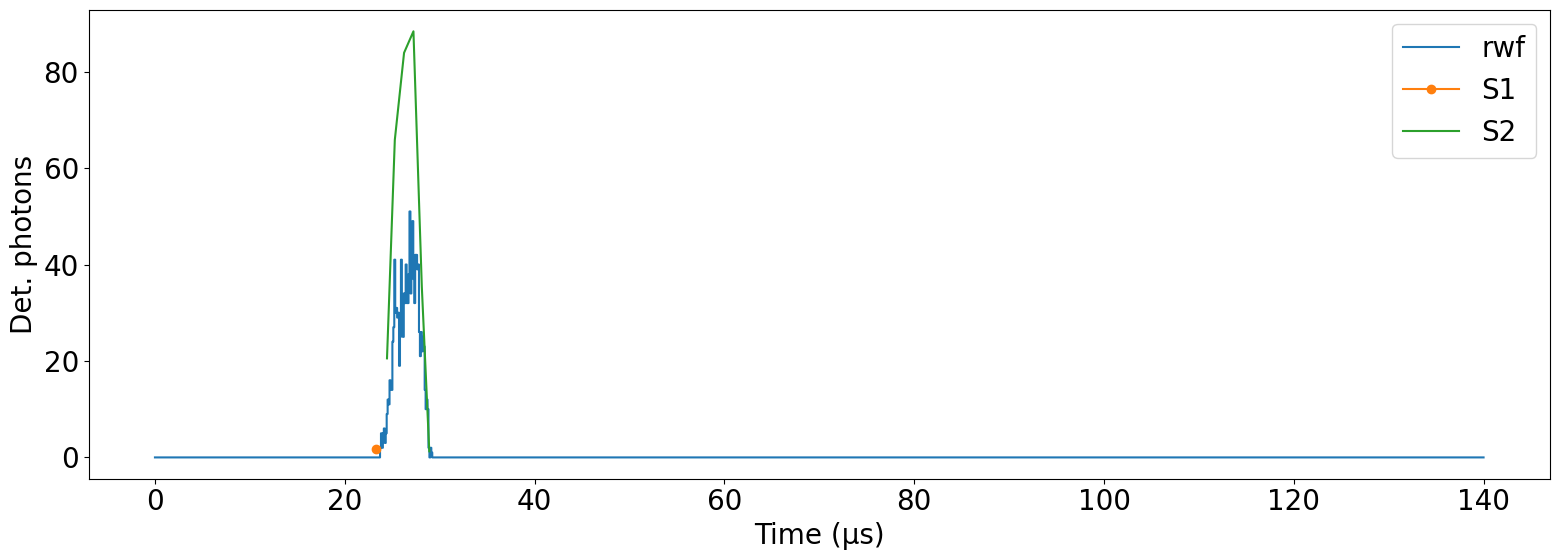

In [227]:
plt.figure(figsize=(16, 6))
evt_number = 0
print(evt_number)
with tb.open_file(filepath_wf, 'r') as h5in:
    pmt_rwf = h5in.root.pmtrd[evt_number][3]#[0]
    t = np.linspace(0, len(pmt_rwf)*pmt_sample_size, len(pmt_rwf))
    plt.plot(t, pmt_rwf, drawstyle='steps', lw=1.5, label='rwf')
    plt.xlabel('Time (µs)')
    plt.ylabel('Det. photons')

with tb.open_file(filepath_pm, 'r') as h5in:
    s1 = s1s[s1s.event==evt_list[evt_number]]
    s2 = s2s[s2s.event==evt_list[evt_number]]
    #print(s2.time)
    plt.plot(s1.time/ns_to_us, s1.ene, label='S1', marker='o')
    #print(s1.time/ns_to_us, float(s1.ene))
    plt.plot(s2.time/ns_to_us, s2.ene/rebin_size, label='S2')
    plt.xlabel('Time (µs)')
    plt.ylabel('Det. photons')
  
    plt.legend()
plt.tight_layout()

# Check kDST (Theodora)

In [228]:
#main_path    = '/home/investigator/GanEss/GanESS_G4Sim/simGanESS/results/100/'
#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_mod_2_wt_EL/simGanESS/'
#main_path   = '/home/investigator/GanEss/GanESS_G4Sim_3/simGanESS/'

#filepath_kd  = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/run_2_theodora.h5'
filepath_kd = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/GanESS_G4Sim_alu_study/simGanESS/oldresults/theodora_100000.h5'
filepath_kd = '/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/G4_simulations/GanESS_G4Sim/simGanESS/run_'+run_nb+'_theodora.h5'

#filename_kd  = 'theodora.h5'
#filepath_kd  = main_path + filename_kd
#filepath_kd  = main_path + filename_pm
!ptdump $filepath_kd
#!ptdump -v $filepath_wf:/pmtrd
!ptdump -v $filepath_kd:/DST/Events
dst = pd.read_hdf(filepath_kd, "/DST/Events")
print(dst['S2e'])




/ (RootGroup) ''
/DST (Group) ''
/DST/Events (Table(245,)shuffle, zlib(4)) 'KDST Events'
/Filters (Group) ''
/Filters/s12_selector (Table(7789,)shuffle, zlib(4)) 'Event has passed filter flag'
/Run (Group) ''
/Run/events (Table(245,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(245,)shuffle, zlib(4)) 'run info table'
/config (Group) ''
/config/adelma (Table(12,)shuffle, zlib(4)) 'configuration for adelma'
/config/thekla (Table(24,)shuffle, zlib(4)) 'configuration for thekla'
/config/theodora (Table(30,)shuffle, zlib(4)) 'configuration for theodora'
/DST/Events (Table(245,)shuffle, zlib(4)) 'KDST Events'
  description := {
  "event": Int64Col(shape=(), dflt=0, pos=0),
  "time": Float64Col(shape=(), dflt=0.0, pos=1),
  "s1_peak": UInt16Col(shape=(), dflt=0, pos=2),
  "s2_peak": UInt16Col(shape=(), dflt=0, pos=3),
  "nS1": UInt16Col(shape=(), dflt=0, pos=4),
  "nS2": UInt16Col(shape=(), dflt=0, pos=5),
  "S1w": Float64Col(shape=(), dflt=0.0, pos=6),
  "S1h": Float64Col(shape=()

In [229]:
dst.tail()

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Nsipm,DT,Z,Zrms,X,Y,R,Phi,Xrms,Yrms
240,7668,1.533665e+10,0,0,1,1,100.0,2.391711,2.391711,23300.0,...,0,3.429793,3.429793,1.087236,-7.082851,9.821341,12.108902,2.195589,21.809593,23.851707
241,7702,1.540567e+10,0,0,1,1,100.0,0.732415,0.732415,23100.0,...,0,4.130078,4.130078,1.093607,-7.231235,10.326161,12.606362,2.181712,21.988281,23.741097
242,7710,1.542126e+10,0,0,1,1,100.0,1.998334,1.998334,29700.0,...,0,-3.255399,-3.255399,1.057011,-5.111641,10.111228,11.329864,2.038867,22.329226,23.537498
243,7766,1.553243e+10,0,0,1,1,200.0,1.477004,2.941350,29500.0,...,0,-2.269824,-2.269824,1.068705,-6.876279,9.192277,11.479598,2.213048,21.651328,24.288242
244,7789,1.557915e+10,0,0,1,1,100.0,0.991939,0.991939,23500.0,...,0,4.029854,4.029854,1.071978,-7.230085,9.679509,12.081681,2.212341,21.674252,24.011068


3519.798828125


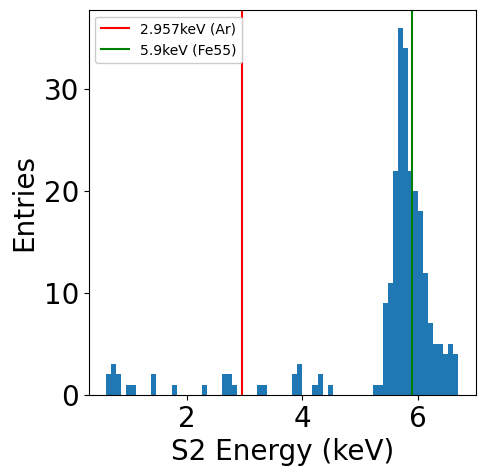

In [232]:
plt.figure(figsize = (5,5))
#S2_ene = dst.S2e * 5.9 / 4605.281066982388
S2_ene = dst.S2e * 5.9 /3098

print(dst.S2e.max())
#S2_ene = dst.S2e * 5.9 / 13956.638672
plt.hist(S2_ene, 70)


plt.xlabel('S2 Energy (keV)')
plt.ylabel('Entries')
#plt.yscale('log')

#ene_line = [1.486, 1.557, 2.957, 5.9]
ene_line = [ 2.957, 5.9]
colors = ['red', 'green', 'blue', 'orange']
labels = ['1.486keV (Al)', '1.557keV (Al)', '2.957keV (Ar)', '5.9keV (Fe55)']
labels = [ '2.957keV (Ar)', '5.9keV (Fe55)']

for ene, color, label in zip(ene_line, colors, labels):
    plt.axvline(ene, color=color, linestyle='-', linewidth=1.5, label=label)
plt.legend(loc='upper left', fontsize=10, framealpha=1)

#print(min(kdst.S2e), max(kdst.S2e))



ValueError: `ydata` must not be empty!

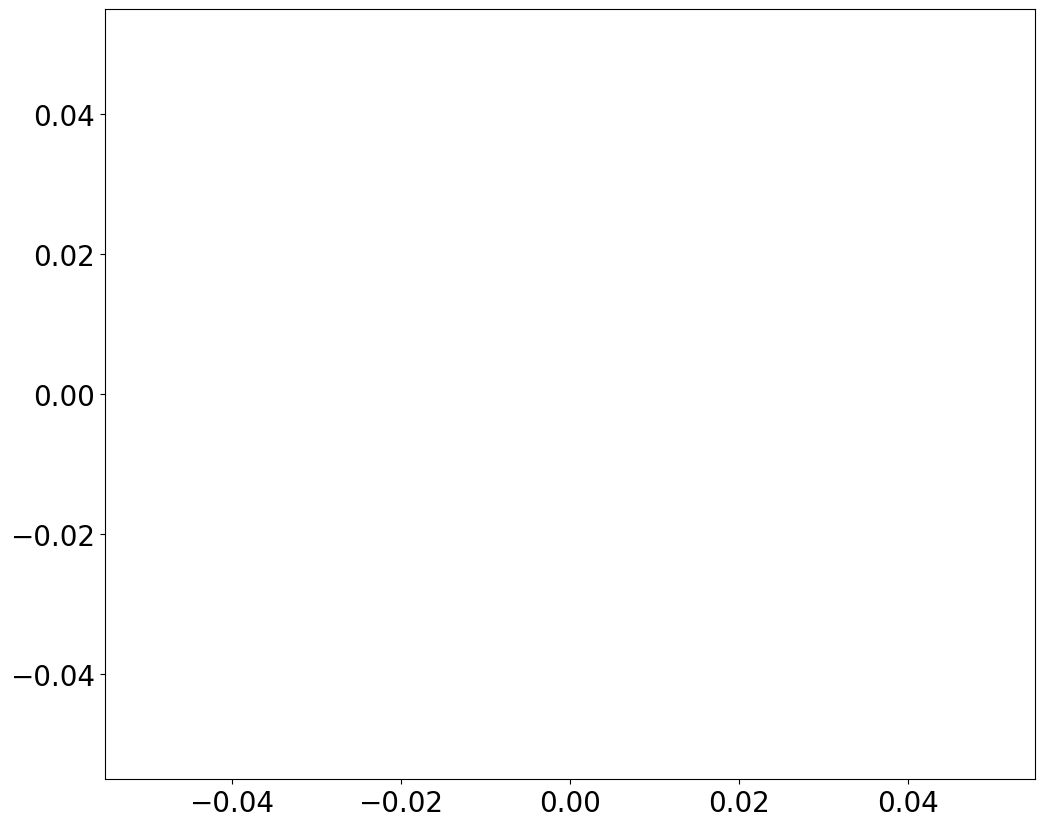

In [231]:
bins_ = np.arange(0, 8, 10)
bin_centers = (bins_[1:] + bins_[:-1]) / 2

def gauss(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

n, bins, patches = plt.hist(S2_ene, bins=bins_)
y = n

p0 = (200, 5.9, 2)
popt, pcov = curve_fit(gauss, bin_centers, y, p0=p0)
y_fit = gauss(bin_centers, *popt)
err = np.sqrt(np.diag(pcov))

amp1 = popt[0]
mu1 = popt[1]
sigma1 = popt[2]

amp1_err = err[0]
mu1_err = err[1]
sigma1_err = err[2]

print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')

plt.plot(bin_centers, y_fit, color='r', linestyle='dashed')

plt.xlabel('Charge (mV)')
#plt.xlabel('Nb of AP')
plt.ylabel('Counts')


plt.legend()
plt.show()


In [ ]:
plt.figure()
plt.hist(kdst.S2e, 100);
plt.xlabel('S2 Energy (pes)')
plt.ylabel('Entries')

print(min(kdst.S2e), max(kdst.S2e))

a = 600
b = 1000

gauss2 = []

for values in kdst.S2e:
    if a <= values <= b:
        gauss2.append(values)

plt.figure()
#plt.hist(gauss1, 100);
#plt.xlabel('S2 Energy (pes)')
#plt.ylabel('Entries')

def gauss(x,amp,mu,sigma):
    return amp*np.exp(-(x-mu)**2/(2*sigma**2))

x = np.linspace(a, b, 200)

n,bins,patches = plt.hist(gauss2, bins=200, range=(a,b))
#print(n,bins,patches)

y = n

moy = sum(gauss2)/len(gauss2)
#print("moy", moy)

     

popt, pcov = curve_fit(gauss,x,y,p0=(3.06913166,764.19105183,50.90685136))

y = gauss(x,popt[0],popt[1],popt[2])

plt.plot(x,y,color='r',linestyle='dashed')

print(popt)



#popt,pcov = curve_fit(gauss,x,y,p0=())


In [123]:
plt.figure()
plt.hist(kdst.S1e, 1000);
plt.xlabel('S1 Energy (pes)')

plt.ylabel('Entries')

NameError: name 'kdst' is not defined

<Figure size 1200x1000 with 0 Axes>

In [124]:
print(kdst)

NameError: name 'kdst' is not defined

# Event reconstruction

In [83]:
pmt_rad = 25.4/2 #mm
pmt_PsX= [-15.573, 20.68, -36.253, 0., 36.253, -20.68, 15.573]
pmt_PsY= [-32.871, -29.922, -2.949, 0., 2.949, 29.922, 32.871]

mesh_rad = 104./2 #mm

NameError: name 'kdst' is not defined

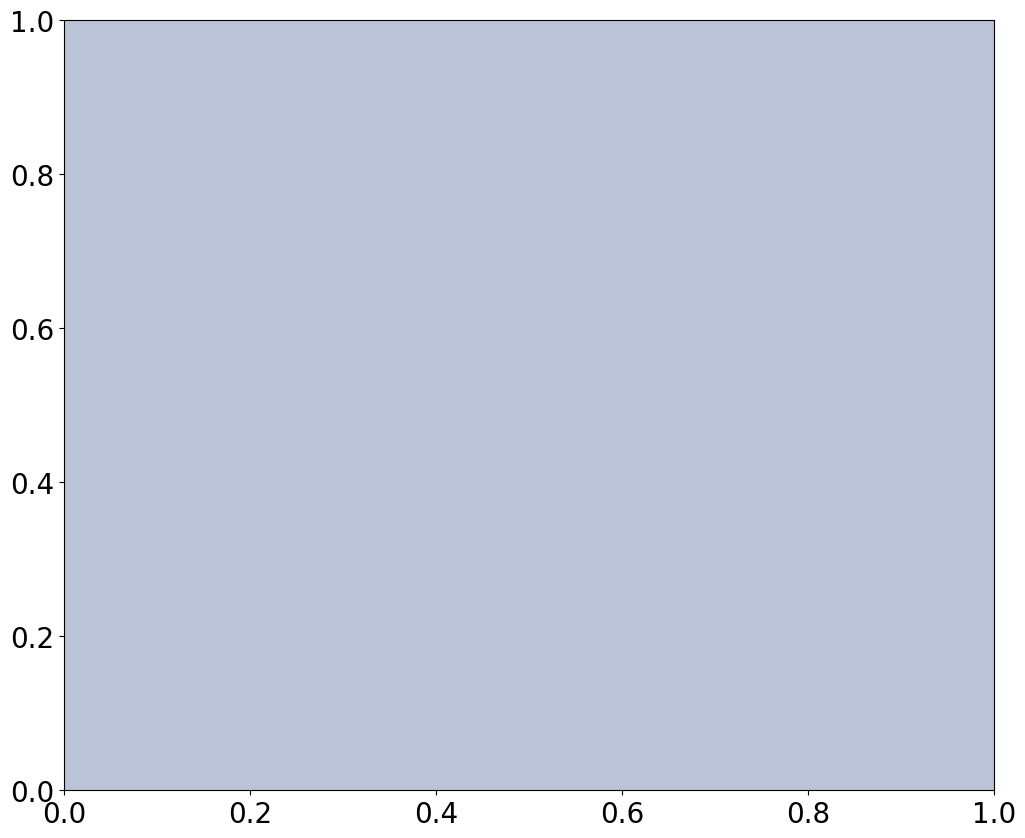

In [84]:
circle_mesh = plt.Circle((0,0), mesh_rad, alpha=0.1, color = 'red')
plt.gca().add_patch(circle_mesh)

circle0 = plt.Circle((pmt_PsX[0],pmt_PsY[0]), pmt_rad, alpha=0.3)
circle1 = plt.Circle((pmt_PsX[1],pmt_PsY[1]), pmt_rad, alpha=0.3)
circle2 = plt.Circle((pmt_PsX[2],pmt_PsY[2]), pmt_rad, alpha=0.3)
circle3 = plt.Circle((pmt_PsX[3],pmt_PsY[3]), pmt_rad, alpha=0.3)
circle4 = plt.Circle((pmt_PsX[4],pmt_PsY[4]), pmt_rad, alpha=0.3)
circle5 = plt.Circle((pmt_PsX[5],pmt_PsY[5]), pmt_rad, alpha=0.3)
circle6 = plt.Circle((pmt_PsX[6],pmt_PsY[6]), pmt_rad, alpha=0.3)
plt.gca().add_patch(circle0)
plt.gca().add_patch(circle1)
plt.gca().add_patch(circle2)
plt.gca().add_patch(circle3)
plt.gca().add_patch(circle4)
plt.gca().add_patch(circle5)
plt.gca().add_patch(circle6)

plt.scatter(kdst.X, kdst.Y, color='orange', label = 'RMS positions')
plt.xlabel('X position')
plt.ylabel('Y position')
#plt.legend()

In [85]:
print(kdst.X)

NameError: name 'kdst' is not defined